# 17.1.1 锁定 Lorenz 稀疏发现的主张

## 学习目标与先修知识

从论文中提取方程发现任务，确定训练数据、候选字典和预测检验。

先修：4.6 Lorenz 系统；14.4 稀疏辨识。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

给出一段 Lorenz 轨迹（trajectory），怎样从数据找回变化规律？先列出候选方程项，再用系数和新初态上的预测检验结果。

In [1]:
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先计算一个可手算的数值，再提出本节需要核验的主张。

In [2]:
x,y,z=-8.,7.,27.;print("给定初态的导数：",[10*(y-x),x*(28-z)-y,x*y-(8/3)*z])

给定初态的导数： [150.0, -15.0, -128.0]


## 模型假设

R18 固定 arXiv:1509.03580v1。原论文 Lorenz 案例使用 σ=10、ρ=28、β=8/3，初态 (-8,7,27)，0—100 归一化时间、步长 0.001，并考虑至五次多项式。这里的 Lorenz 状态（state）和时间均无量纲（dimensionless）。本课程在普通 CPU 上取前 4 归一化时间、步长 0.01 和二次字典；用这一配置研究字典筛选与短窗预测。导数（derivative）真值只用于无噪声参照，噪声实验单独声明。

## 数学解释与推导

令 $X=[x,y,z]$，候选字典 $\Theta(X)$ 包含常数、一次、二次直至指定最高次数项，寻找稀疏系数矩阵（matrix） $\Xi$ 使 $\dot X\approx\Theta(X)\Xi$。真实 Lorenz 项为 $\dot x=10(y-x)$、$\dot y=28x-y-xz$、$\dot z=xy-8z/3$。方程项与独立初态上的短时预测是两个证据；混沌（chaos）系统的长时逐点误差不能单独判定方程错误。

## 核心实现

以下短函数展示方程、数值步骤和可修改的计算顺序。

In [3]:
def lorenz_rhs(state, sigma=10., rho=28., beta=8./3.):
    x,y,z=np.asarray(state,dtype=float)
    return np.array([sigma*(y-x),x*(rho-z)-y,x*y-beta*z],dtype=float)


def rk4_path(rhs, initial, h, steps):
    state=np.asarray(initial,dtype=float)
    rows=[state.copy()]
    for _ in range(steps):
        k1=np.asarray(rhs(state));k2=np.asarray(rhs(state+h*k1/2))
        k3=np.asarray(rhs(state+h*k2/2));k4=np.asarray(rhs(state+h*k3))
        state=state+h*(k1+2*k2+2*k3+k4)/6
        rows.append(state.copy())
    return np.asarray(rows)


def polynomial_library(states, degree=2):
    states=np.atleast_2d(np.asarray(states,dtype=float))
    terms=[()]
    for order in range(1,degree+1):
        terms.extend(itertools.combinations_with_replacement(range(states.shape[1]),order))
    matrix=np.column_stack([np.prod(states[:,indices],axis=1) if indices else np.ones(len(states)) for indices in terms])
    labels=['1' if not indices else '*'.join('xyz'[i] if i<3 else f'x{i}' for i in indices) for indices in terms]
    return matrix,labels

## 对照实验

观察前 4 个时间单位的轨迹，并数出二次字典中的候选项。轨迹提供数据，字典提供待估计的方程结构。

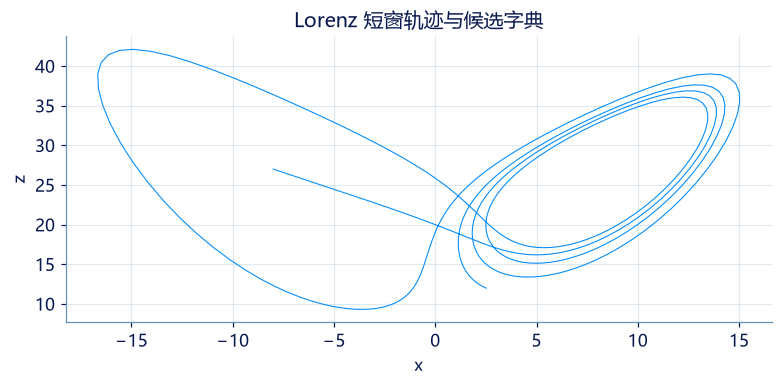

课程窗口 401 字典列 10 ；原文另使用更长窗口与五次字典


In [4]:
path=rk4_path(lorenz_rhs,[-8.,7.,27.],.01,400);library,labels=polynomial_library(path,2)
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(path[:,0],path[:,2],lw=.7,color=BLUE);ax.set(xlabel="x",ylabel="z",title="Lorenz 短窗轨迹与候选字典");ax.grid(alpha=.2);plt.show()
print("课程窗口",len(path),"字典列",len(labels),"；原文另使用更长窗口与五次字典")

## 结果解释

图中展示了给定方程生成的短窗轨迹。二次字典把每个状态展开成 10 个候选项；下一章将用轨迹及导数估计各项系数，再从新初态检验预测。

### 独立核对

把初态代入 Lorenz 三条方程，核对导数，并检查二次字典的列顺序。

In [5]:
assert labels==["1","x","y","z","x*x","x*y","x*z","y*y","y*z","z*z"]
np.testing.assert_allclose(lorenz_rhs([-8.,7.,27.]),[150.,-15.,-128.],rtol=0,atol=1e-10)
print("独立代入原方程及字典顺序核验通过。")

独立代入原方程及字典顺序核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/17-01-%E7%A0%94%E7%A9%B6%E9%97%AE%E9%A2%98%E4%B8%8E%E8%AF%81%E6%8D%AE/explore/)。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：原论文参数与课程窗口

哪一种陈述可由本节缩减 Lorenz 实验支持？

- **A.** 原论文的全部性能数字已经复现
- **B.** 二次字典短窗口恢复给定方程项
- **C.** 真实生理系统已被辨识
- **D.** 任意长时混沌（chaos）轨迹（trajectory）逐点一致

[作答：原论文参数与课程窗口](http://127.0.0.1:8000/chapters/17-01-%E7%A0%94%E7%A9%B6%E9%97%AE%E9%A2%98%E4%B8%8E%E8%AF%81%E6%8D%AE/practice/?question=p17-c1s1-choice1)

### 第 2 题 · 单项选择题：真值导数的范围

使用已知 Lorenz 方程提供导数（derivative），主要消除了什么难题？

- **A.** 测试轨迹（trajectory）划分
- **B.** 从噪声观测（observation）估导数
- **C.** 多项式列顺序
- **D.** 初值（initial condition）变化

[作答：真值导数的范围](http://127.0.0.1:8000/chapters/17-01-%E7%A0%94%E7%A9%B6%E9%97%AE%E9%A2%98%E4%B8%8E%E8%AF%81%E6%8D%AE/practice/?question=p17-c1s1-choice2)

### 第 3 题 · Python 计算题：原方程瞬时导数

原论文报告从数据中发现 Lorenz 方程。本节究竟能核查方程项、系数、短时预测，还是全部长期混沌（chaos）轨迹（trajectory）？本题计算“原方程瞬时导数（derivative）”：依次计算 sigma*(y-x)、x*(rho-z)-y、x*y-beta*z；状态（state）与时间均按 Lorenz 无量纲（dimensionless）形式给出。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    state: list[float],
    sigma: float,
    rho: float,
    beta: float,
) -> list[float]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[float]` | 按 x、y、z 顺序的无量纲当前状态。 | 1 |
| `sigma` | `float` | 归一化 Lorenz 参数。 | 1 |
| `rho` | `float` | 归一化 Lorenz 参数。 | 1 |
| `beta` | `float` | 归一化 Lorenz 参数。 | 1 |

**返回值**

直接返回 rates（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rates` | `list[float]` | 三个状态对归一化时间的变化率。 | 1 |

**计算规则**

依次计算 sigma*(y-x)、x*(rho-z)-y、x*y-beta*z；状态与时间均按 Lorenz 无量纲形式给出。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入（input）满足模型（model）和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 按 x、y、z 顺序的无量纲当前状态。 | [-8.0, 7.0, 27.0] | 1 |
| sigma | 归一化 Lorenz 参数。 | 10 | 1 |
| rho | 归一化 Lorenz 参数。 | 28 | 1 |
| beta | 归一化 Lorenz 参数。 | ≈ 2.666667 | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [-8.0, 7.0, 27.0]
sigma = 10.0
rho = 28.0
beta = 2.6666666666666665

result = solve(state, sigma, rho, beta)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rates | 三个状态对归一化时间的变化率。 | [150.0, -15.0, -128.0] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [150.0, -15.0, -128.0]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；依次计算 sigma*(y-x)、x*(rho-z)-y、x*y-beta*z；状态与时间均按 Lorenz 无量纲形式给出。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：原方程瞬时导数](http://127.0.0.1:8000/chapters/17-01-%E7%A0%94%E7%A9%B6%E9%97%AE%E9%A2%98%E4%B8%8E%E8%AF%81%E6%8D%AE/practice/?question=p17-lorenz-vector)

### 第 4 题 · Python 计算题：二次候选项顺序

原论文报告从数据中发现 Lorenz 方程。本节究竟能核查方程项、系数、短时预测，还是全部长期混沌（chaos）轨迹（trajectory）？本题计算“二次候选项顺序”：返回 [1,x,y,z,x²,xy,xz,y²,yz,z²]。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    state: list[float],
) -> list[float]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[float]` | 三个状态（state） x、y、z。 | 模型状态 |

**返回值**

直接返回 terms（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `terms` | `list[float]` | 常数、一次和二次项的固定顺序。 | 混合 |

**计算规则**

返回 [1,x,y,z,x²,xy,xz,y²,yz,z²]。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入（input）满足模型（model）和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 三个状态（state） x、y、z。 | [2.0, 3.0, 4.0] | 模型状态 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [2.0, 3.0, 4.0]

result = solve(state)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| terms | 常数、一次和二次项的固定顺序。 | [1.0, 2.0, 3.0, 4.0, 4.0, 6.0, 8.0, 9.0, 12.0, 16.0] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0,
                   2.0,
                   3.0,
                   4.0,
                   4.0,
                   6.0,
                   8.0,
                   9.0,
                   12.0,
                   16.0]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；返回 [1,x,y,z,x²,xy,xz,y²,yz,z²]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：二次候选项顺序](http://127.0.0.1:8000/chapters/17-01-%E7%A0%94%E7%A9%B6%E9%97%AE%E9%A2%98%E4%B8%8E%E8%AF%81%E6%8D%AE/practice/?question=p17-candidate-row)

**原始参考**

[Brunton、Proctor 与 Kutz，arXiv:1509.03580v1](https://arxiv.org/abs/1509.03580v1)